# ML Notebook — Cambodia Education Forecast (Lag Features Version)

This notebook implements a **Lag-based Forecasting** approach. Instead of projecting features (like number of classrooms or population) into the future using trend lines, we use the historical values of the targets themselves (and key features) from previous years to predict the current year.

**Changes from 02_modelling:**
- **Lag Features**: Created `lag_1` and `lag_2` for enrollment, dropout, and teacher quality.
- **No Feature Projection**: We do not guess what the 2030 features will be.
- **Short Horizon**: Focus on predicting 2025 and 2026 using 2016-2024 data.
- **Validation**: Strict split (Train: 2016-2024, Test: 2025-2026).

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & Engineer Targets

In [25]:
import os
if os.path.exists('../data/cleaned_new_data.csv'):
    df = pd.read_csv('../data/cleaned_new_data.csv')
else:
    df = pd.read_csv('data/cleaned_new_data.csv')
df = df[df['Year'] != 2021].reset_index(drop=True)

# Targets
repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)

overage_cols = ['pct_overage_enrollment_primary',
                'pct_overage_enrollment_lower_sec',
                'pct_overage_enrollment_upper_sec']
df['over_age_enrollment_total'] = df[overage_cols].sum(axis=1)
df['avg_transition_rate'] = df[['transition_rate_lower_sec_total',
                                 'transition_rate_upper_sec_total']].mean(axis=1)

df['kids_population'] = df[['pop_aged6_total','pop_aged6_11_total',
                              'pop_aged12_14_total','pop_aged15_17_total']].sum(axis=1)
df['bad_qual_teacher']  = df[['teaching_staff_edu_primary',
                               'teaching_staff_edu_lower_sec',
                               'teaching_staff_edu_upper_sec']].sum(axis=1)
df['good_qual_teacher'] = df[['teaching_staff_edu_graduate',
                               'teaching_staff_edu_postgrad',
                               'teaching_staff_edu_phd']].sum(axis=1)

edu_levels = ['primary','lower_sec','upper_sec','graduate','postgrad','phd']
weights    = {'primary':1,'lower_sec':2,'upper_sec':3,'graduate':4,'postgrad':5,'phd':6}

df['no_pedagogy_ratio'] = (
    df[[f'teaching_staff_no_pedagogy_{l}' for l in edu_levels]].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_high_qual_ratio'] = (
    df[['teaching_staff_edu_graduate','teaching_staff_edu_postgrad','teaching_staff_edu_phd']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_low_qual_ratio'] = (
    df[['teaching_staff_edu_primary','teaching_staff_edu_lower_sec','teaching_staff_edu_upper_sec']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)

for prefix in ['teaching_staff_edu','non_teaching_staff_edu','teaching_staff_no_pedagogy']:
    weighted_sum = sum(df[f'{prefix}_{l}'] * w for l, w in weights.items())
    total = df[[f'{prefix}_{l}' for l in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f'{prefix}_qual_index'] = weighted_sum / total

print(df.shape)
print(df[['Year','enrollment_total','avg_dropout_rate','teaching_staff_edu_qual_index']].groupby('Year').mean().round(3))


(250, 276)
      enrollment_total  avg_dropout_rate  teaching_staff_edu_qual_index
Year                                                                   
2016         120385.44            14.182                          2.887
2017         123106.40            11.765                          2.936
2018         125730.08            10.903                          2.961
2019         127566.88            10.800                          3.010
2020         128411.40            13.247                          3.017
2022         130631.08            13.512                          3.099
2023         133770.48            12.585                          3.159
2024         136326.16            10.700                          3.190
2025         136928.20             9.753                          3.211
2026         128292.92             9.171                          3.286


## 2. Lag Feature Engineering

We create `lag_1` (previous year) and `lag_2` (two years ago) features. 
This allows the model to learn that "last year's enrollment is a strong predictor of this year's enrollment".

In [26]:
lag_features = ['enrollment_total', 'avg_dropout_rate', 'teaching_staff_edu_qual_index']

df = df.sort_values(['Province', 'Year'])

for feat in lag_features:
    df[f'{feat}_lag1'] = df.groupby('Province')[feat].shift(1)
    df[f'{feat}_lag2'] = df.groupby('Province')[feat].shift(2)

print("Shape before dropping NaNs:", df.shape)
# Drop rows where we don't have lag features (first 2 years per Province)
df = df.dropna(subset=[f'{feat}_lag2' for feat in lag_features])
print("Shape after dropping NaNs:", df.shape)
print("Years remaining:", sorted(df['Year'].unique()))

Shape before dropping NaNs: (250, 282)
Shape after dropping NaNs: (200, 282)
Years remaining: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 3. Relationships: Lag Correlation Heatmap

Let's see how strongly the lagged values correlate with the current values.

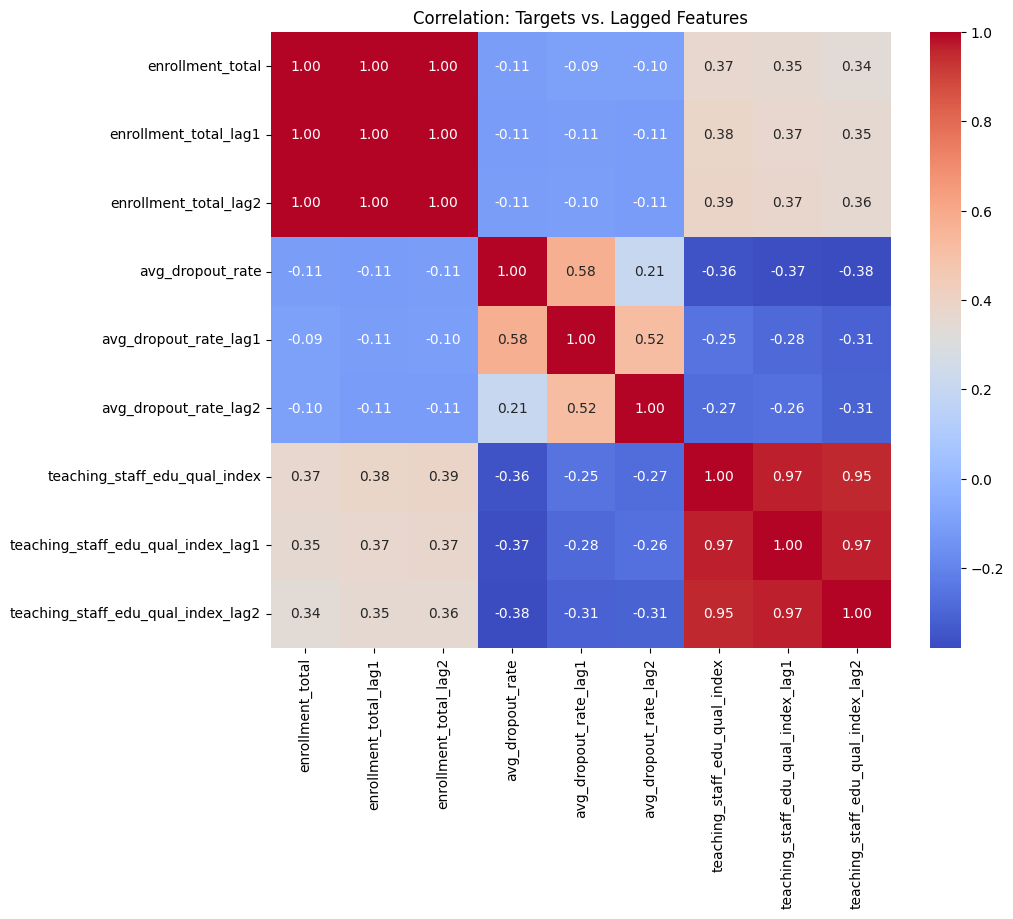

In [27]:
cols_to_corr = [
    'enrollment_total', 'enrollment_total_lag1', 'enrollment_total_lag2',
    'avg_dropout_rate', 'avg_dropout_rate_lag1', 'avg_dropout_rate_lag2',
    'teaching_staff_edu_qual_index', 'teaching_staff_edu_qual_index_lag1', 'teaching_staff_edu_qual_index_lag2'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation: Targets vs. Lagged Features")
plt.show()

## 4. Feature Selection & Transformation

We will keep the original numeric features but focus on the lagged ones. We skip the complex projection step.

In [28]:
features_enrollment = ['enrollment_total_lag1', 'enrollment_total_lag2', 'total_staff_total', 'num_classrooms']
features_dropout    = ['avg_dropout_rate_lag1', 'avg_dropout_rate_lag2', 'avg_transition_rate', 'teaching_staff_edu_qual_index']
features_teacher    = ['teaching_staff_edu_qual_index_lag1', 'teaching_staff_edu_qual_index_lag2', 'principal_avg_service_years', 'pb_fund_per_school_riel']

# Outlier removal
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=['number']).dropna()
    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)
    return df.loc[numeric_df.index[preds == 1]].copy()

df = remove_outliers_iforest(df)

## 5. Model Training (2016-2024 for Train, 2025-2026 for Test)

We evaluate how well the model predicts the known 2025-2026 values using the lagged features.


--- Results for enrollment_total ---
        Model      R2        MAE       RMSE
        Ridge  0.9884  5738.5156  8960.9117
      XGBoost  0.9875  5756.9037  9281.9349
Random Forest  0.9870  5786.6271  9466.2889
        Lasso  0.9870  6020.5420  9476.2642
          GBR  0.9858  6012.3221  9895.0438
 SVR (Linear)  0.0001 70639.9523 83055.1510
    SVR (RBF) -0.0037 70711.7145 83211.9098


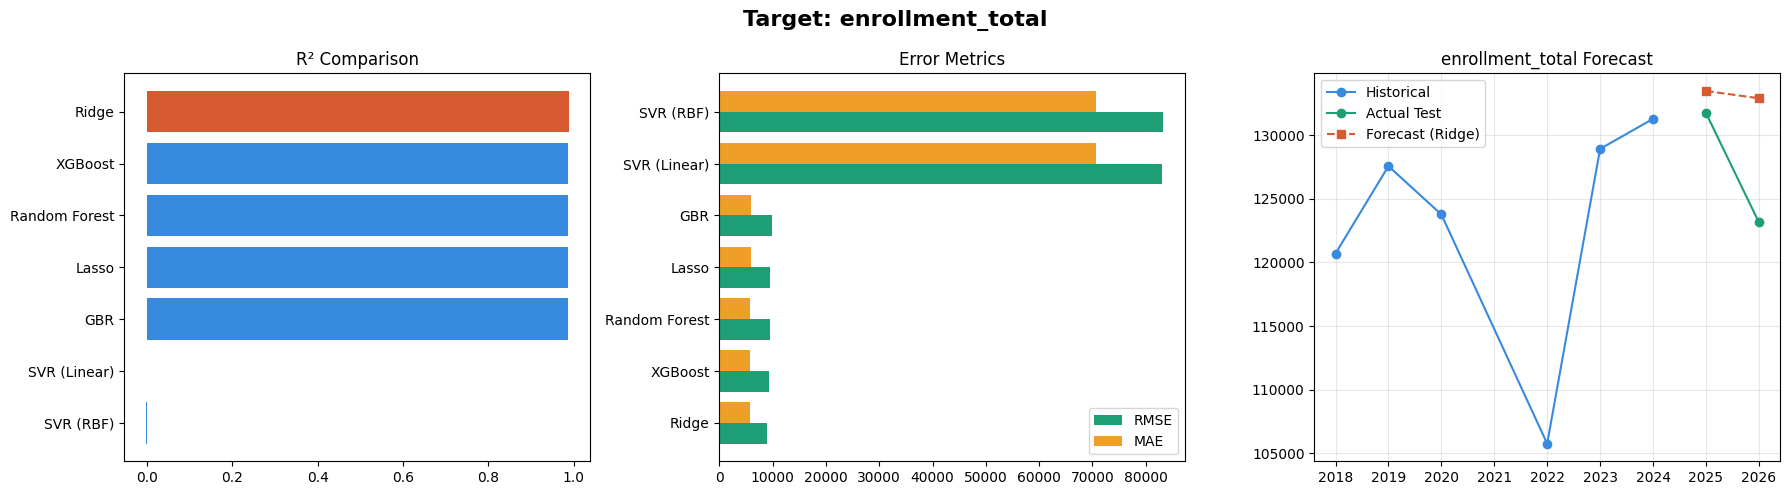


--- Results for avg_dropout_rate ---
        Model      R2    MAE   RMSE
 SVR (Linear)  0.2267 1.2428 1.4443
        Ridge -0.1251 1.5250 1.7422
    SVR (RBF) -0.1326 1.4043 1.7480
Random Forest -0.1659 1.4689 1.7735
        Lasso -0.2401 1.6167 1.8290
          GBR -0.2919 1.5847 1.8668
      XGBoost -0.6736 1.7458 2.1249


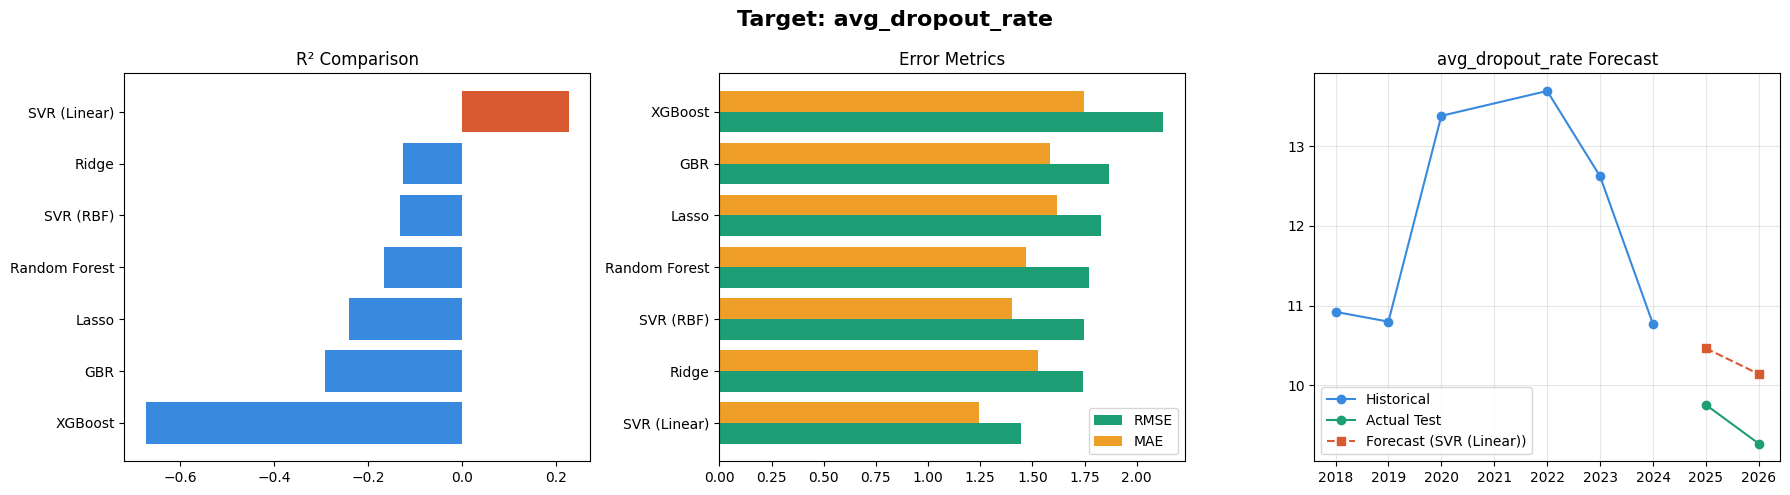


--- Results for teaching_staff_edu_qual_index ---
        Model      R2    MAE   RMSE
 SVR (Linear)  0.9067 0.0393 0.0490
        Ridge  0.8943 0.0435 0.0521
Random Forest  0.8605 0.0500 0.0599
          GBR  0.8541 0.0499 0.0612
      XGBoost  0.8332 0.0549 0.0655
    SVR (RBF)  0.5075 0.0852 0.1125
        Lasso -0.3699 0.1494 0.1876


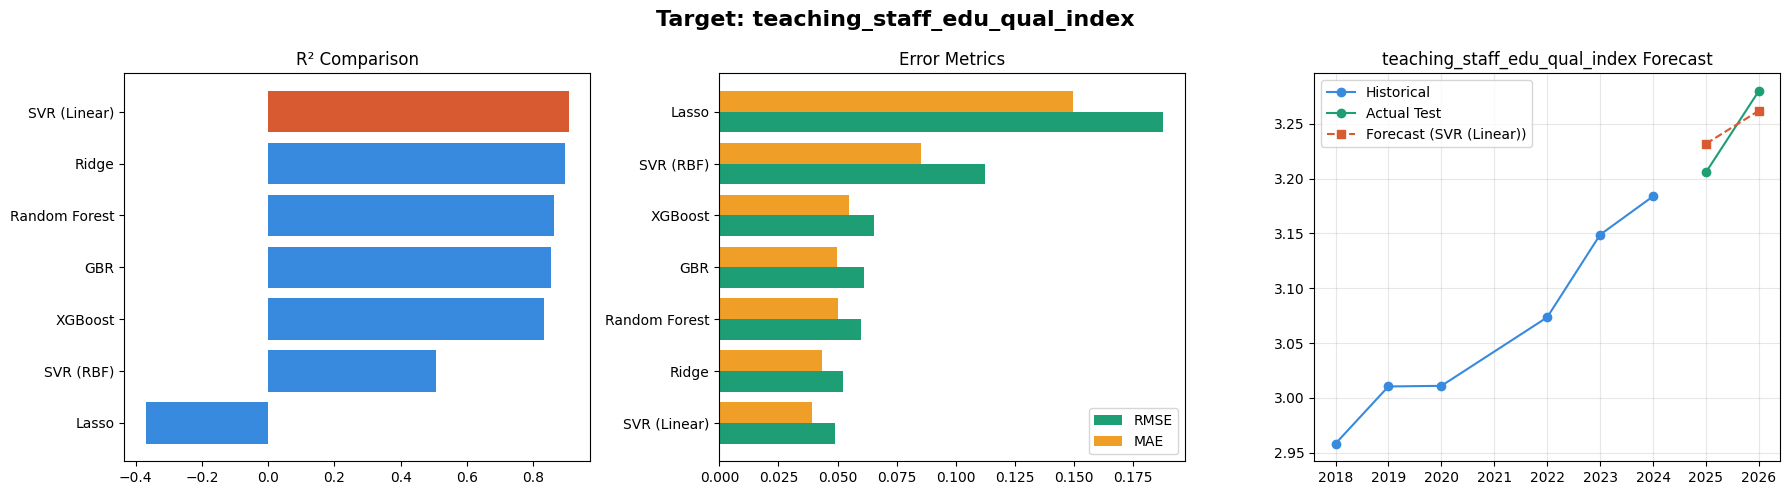

In [29]:
def select_and_forecast_lag(df, target, features, train_years=(2016, 2024), val_years=(2025, 2026)):
    """
    Evaluates 7 models on lag features, selects best, and plots results.
    """
    train_mask = df['Year'].between(*train_years)
    val_mask   = df['Year'].between(*val_years)

    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    X_val   = df.loc[val_mask, features]
    y_val   = df.loc[val_mask, target]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=features)
    X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=features)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_val_sc   = scaler.transform(X_val_imp)

    models = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost':       xgb.XGBRegressor(n_estimators=100, random_state=42),
        'Ridge':         Ridge(alpha=1.0),
        'Lasso':         Lasso(alpha=0.1),
        'GBR':           GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR (RBF)':     SVR(kernel='rbf', C=10, epsilon=0.1),
        'SVR (Linear)':  SVR(kernel='linear', C=1)
    }

    records, val_preds = [], {}
    for name, model in models.items():
        X_tr = X_train_sc if 'SVR' in name else X_train_imp
        X_v  = X_val_sc   if 'SVR' in name else X_val_imp
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_v)
        records.append({
            'Model': name,
            'R2':    round(r2_score(y_val, y_pred), 4),
            'MAE':   round(mean_absolute_error(y_val, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_val, y_pred)), 4)
        })
        val_preds[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R2', ascending=False).reset_index(drop=True)
    best_name = results_df.iloc[0]['Model']
    best_preds = val_preds[best_name]

    print(f"\n--- Results for {target} ---")
    print(results_df.to_string(index=False))

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))

    # 1. R2 Plot
    ax1 = fig.add_subplot(1, 3, 1)
    sorted_r2 = results_df.sort_values('R2')
    colors = ['#D85A30' if m == best_name else '#378ADD' for m in sorted_r2['Model']]
    ax1.barh(sorted_r2['Model'], sorted_r2['R2'], color=colors)
    ax1.set_title('R² Comparison')

    # 2. Error Plot
    ax2 = fig.add_subplot(1, 3, 2)
    x_pos = np.arange(len(results_df))
    ax2.barh(x_pos - 0.2, results_df['RMSE'], 0.4, label='RMSE', color='#1D9E75')
    ax2.barh(x_pos + 0.2, results_df['MAE'], 0.4, label='MAE', color='#EF9F27')
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(results_df['Model'])
    ax2.set_title('Error Metrics')
    ax2.legend()

    # 3. Forecast Plot
    ax3 = fig.add_subplot(1, 3, 3)
    hist_years = sorted(df[df['Year'] < val_years[0]]['Year'].unique())
    hist_vals  = df[df['Year'] < val_years[0]].groupby('Year')[target].mean()
    
    actual_years = sorted(df[df['Year'].between(*val_years)]['Year'].unique())
    actual_vals  = df[df['Year'].between(*val_years)].groupby('Year')[target].mean()
    
    # Aggregate predictions by year
    pred_df = pd.DataFrame({'Year': df.loc[val_mask, 'Year'], 'Pred': best_preds})
    pred_vals = pred_df.groupby('Year')['Pred'].mean()

    ax3.plot(hist_years, hist_vals, label='Historical', color='#378ADD', marker='o')
    ax3.plot(actual_years, actual_vals, label='Actual Test', color='#1D9E75', marker='o')
    ax3.plot(actual_years, pred_vals, label=f'Forecast ({best_name})', color='#D85A30', linestyle='--', marker='s')
    
    ax3.set_title(f'{target} Forecast')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Target: {target}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results_df

res_e = select_and_forecast_lag(df, 'enrollment_total', features_enrollment)
res_d = select_and_forecast_lag(df, 'avg_dropout_rate', features_dropout)
res_t = select_and_forecast_lag(df, 'teaching_staff_edu_qual_index', features_teacher)


## 6. Comparison Table: Original vs. Lag-Based Model

Let's compare the performance of this approach against the previous Feature Projection approach.

In [30]:
comparison_data = {
    'Target': ['Enrollment', 'Dropout Rate', 'Teacher Quality'],
    'Original Model (R2)': [0.9814, -0.0010, 0.5193],
    'Lag-Based Model (R2)': [
        res_e.iloc[0]['R2'],
        res_d.iloc[0]['R2'],
        res_t.iloc[0]['R2']
    ]
}

comp_df = pd.DataFrame(comparison_data)
comp_df['Improvement'] = comp_df['Lag-Based Model (R2)'] - comp_df['Original Model (R2)']
print(comp_df.to_string(index=False))

         Target  Original Model (R2)  Lag-Based Model (R2)  Improvement
     Enrollment               0.9814                0.9884       0.0070
   Dropout Rate              -0.0010                0.2267       0.2277
Teacher Quality               0.5193                0.9067       0.3874
